## IMPLEMENTING A SIMPLIFIED ATTENTION MECHANISM

This schematic diagranm showa the  simple Attention mechanism 

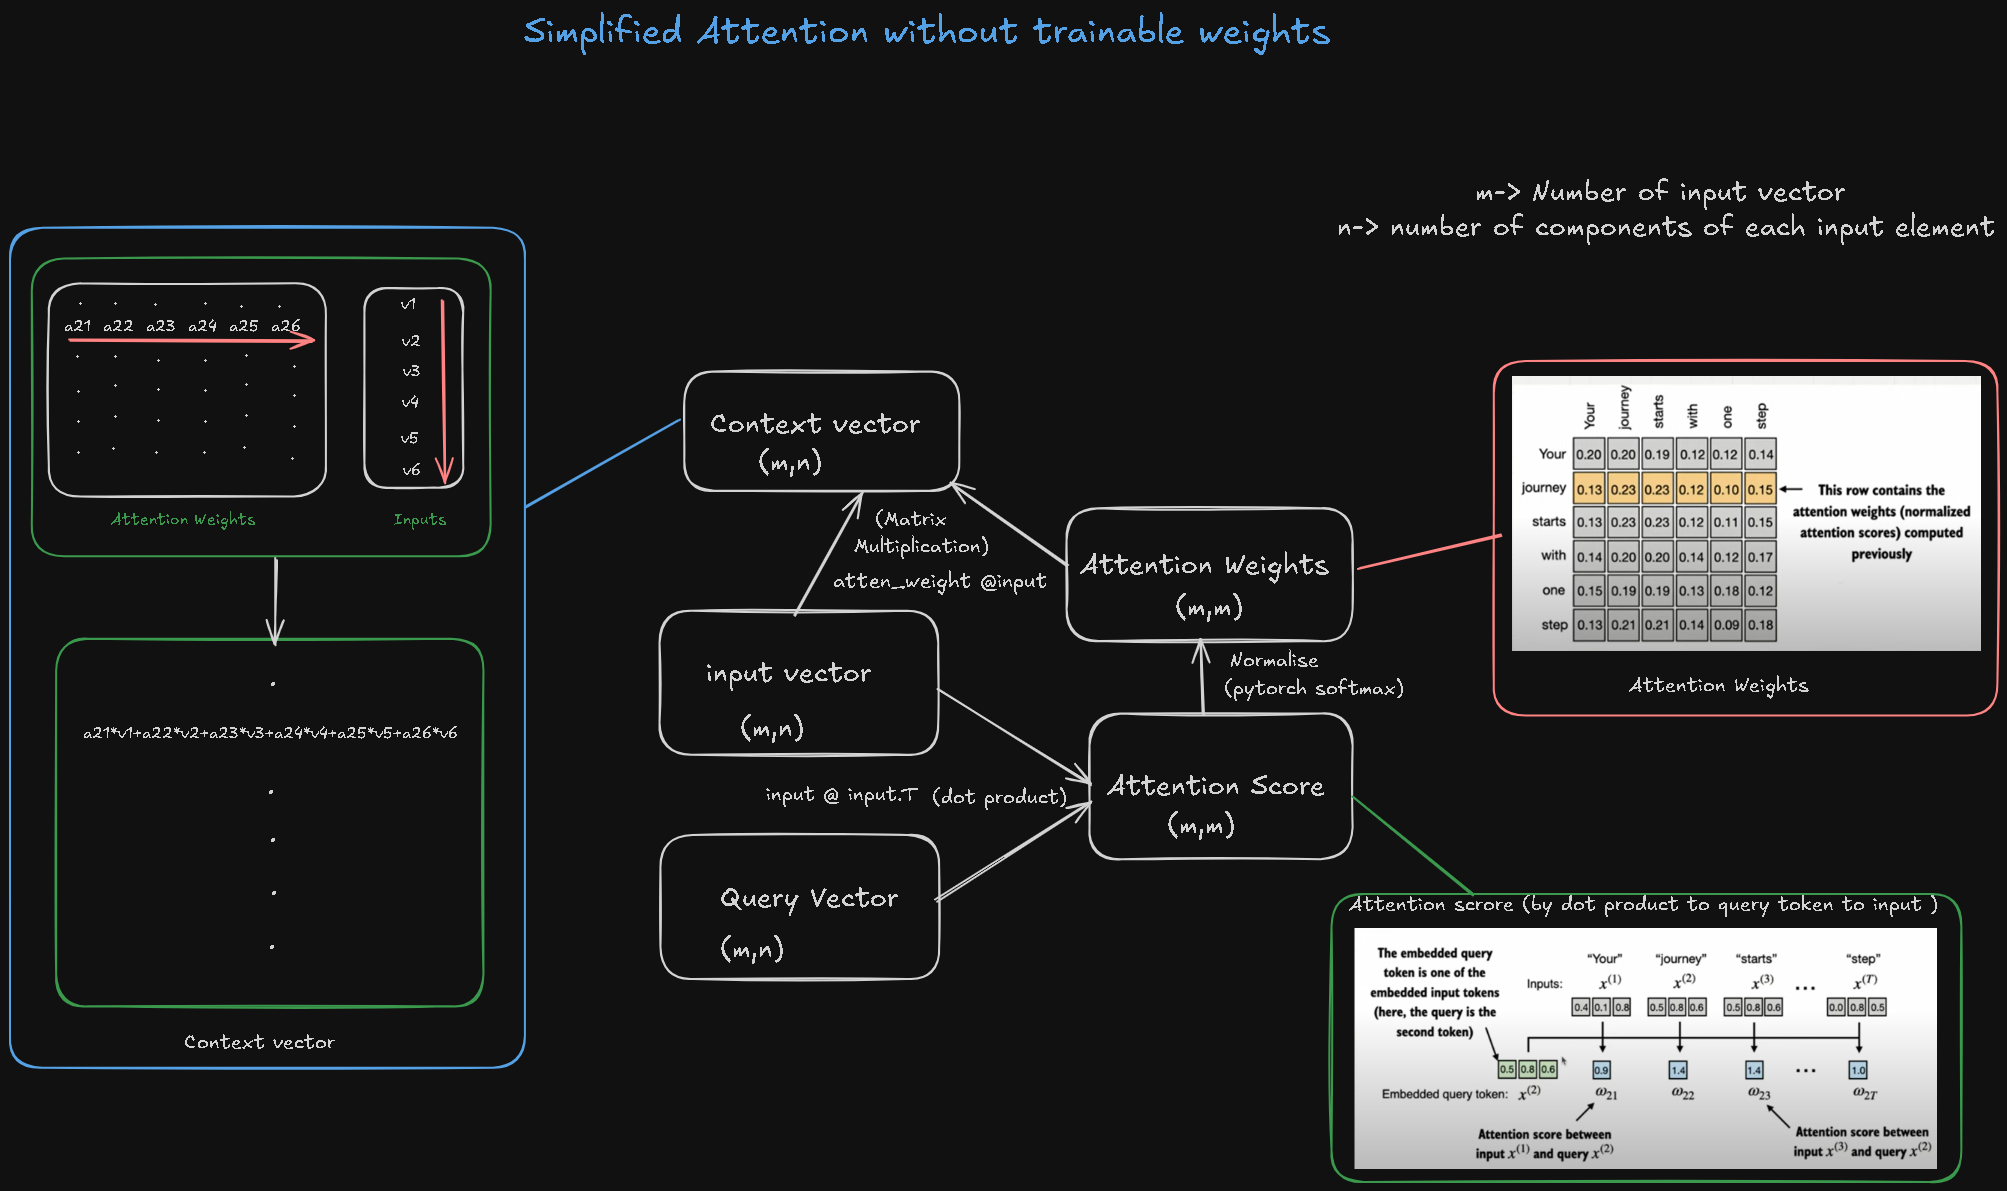

In [1]:
import torch

inputs = torch.tensor(
  [[0.43, 0.15, 0.89], # Your     (x^1)
   [0.55, 0.87, 0.66], # journey  (x^2)
   [0.57, 0.85, 0.64], # starts   (x^3)
   [0.22, 0.58, 0.33], # with     (x^4)
   [0.77, 0.25, 0.10], # one      (x^5)
   [0.05, 0.80, 0.55]] # step     (x^6)
)

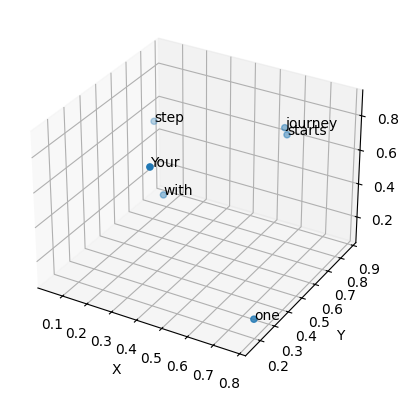

tensor([[0.4300, 0.1500, 0.8900],
        [0.5500, 0.8700, 0.6600],
        [0.5700, 0.8500, 0.6400],
        [0.2200, 0.5800, 0.3300],
        [0.7700, 0.2500, 0.1000],
        [0.0500, 0.8000, 0.5500]])
torch.Size([6, 3])


In [5]:
import matplotlib.pyplot as plt
words = ["Your", "journey", "starts", "with", "one", "step"]

x_coord = inputs[:, 0]
y_coord = inputs[:, 1]
z_coord = inputs[:, 2]


fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x_coord, y_coord, z_coord)
for i, word in enumerate(words):
    ax.text(x_coord[i], y_coord[i], z_coord[i], word)
    
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.show()
print(inputs)
print(inputs.shape) # (6, 3)
# 6 words, each represented by a 3-dimensional vector

## Create 3D plot with vectors from origin to each point, using different colors

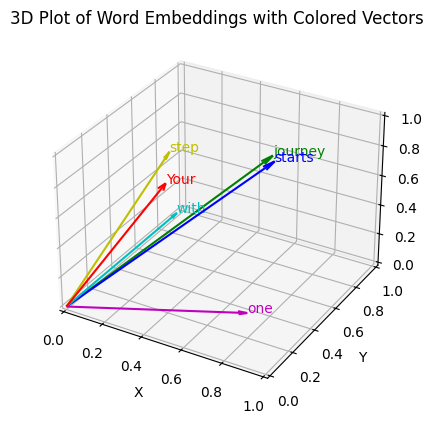

In [6]:
# Create 3D plot with vectors from origin to each point, using different colors
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# Define a list of colors for the vectors
colors = ['r', 'g', 'b', 'c', 'm', 'y']

# Plot each vector with a different color and annotate with the corresponding word
for (x, y, z, word, color) in zip(x_coord, y_coord, z_coord, words, colors):
    # Draw vector from origin to the point (x, y, z) with specified color and smaller arrow length ratio
    ax.quiver(0, 0, 0, x, y, z, color=color, arrow_length_ratio=0.05)
    ax.text(x, y, z, word, fontsize=10, color=color)

# Set labels for axes
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

# Set plot limits to keep arrows within the plot boundaries
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.set_zlim([0, 1])

plt.title('3D Plot of Word Embeddings with Colored Vectors')
plt.show()


 ## Attention Score 
 The attention weights are derives from the vector dot product , if they are alined then it will be heigher.
 
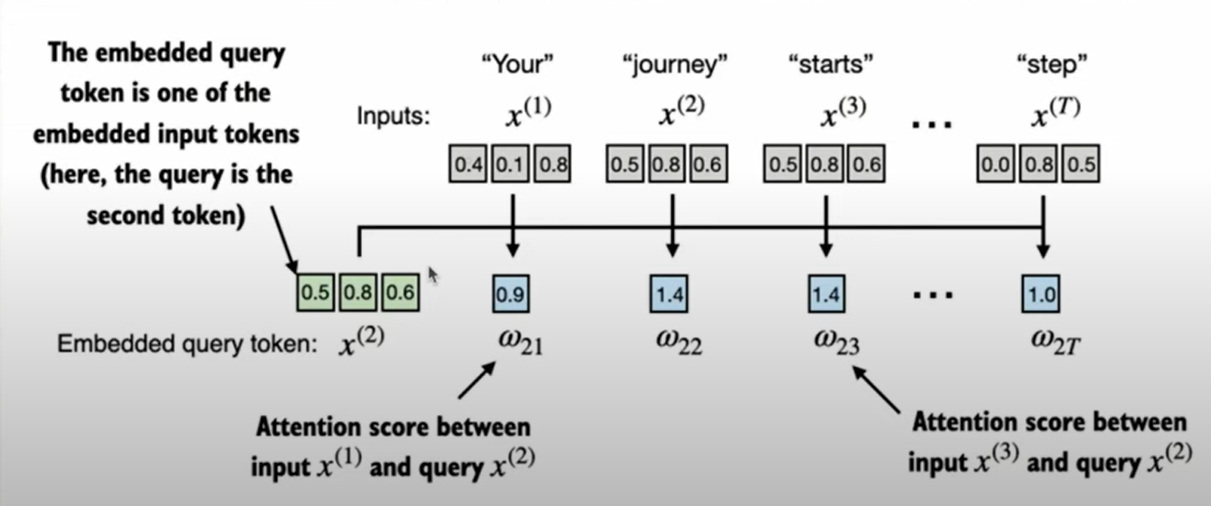

In [9]:
query = inputs[1] #(3,)

atten_score = inputs @ query #(6,3) @ (3,) -> (6,)
print(atten_score) 

tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])


## Attention Weights
To convert it from score to weight  we have to apply **Softmax Normalisation** on it 

<div class="alert alert-block alert-info">
    
In practice, it's more common and advisable to use the softmax function for normalization.

This approach is better at managing extreme values and offers more favorable gradient
properties during training. 

Below is a basic implementation of the softmax function for
normalizing the attention scores: 
</div>

In [11]:
def softmax(x):
    return torch.exp(x) / torch.sum(torch.exp(x))
atten_weights_naive = softmax(atten_score) #(6,)
print(atten_weights_naive)

tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])


<div class="alert alert-block alert-warning">

Note that this naive softmax implementation (softmax_naive) may encounter numerical
instability problems, such as overflow and underflow, when dealing with large or small input
values. 

Therefore, in practice, it's advisable to use the PyTorch implementation of softmax,
which has been extensively optimized for performance:
    
</div>


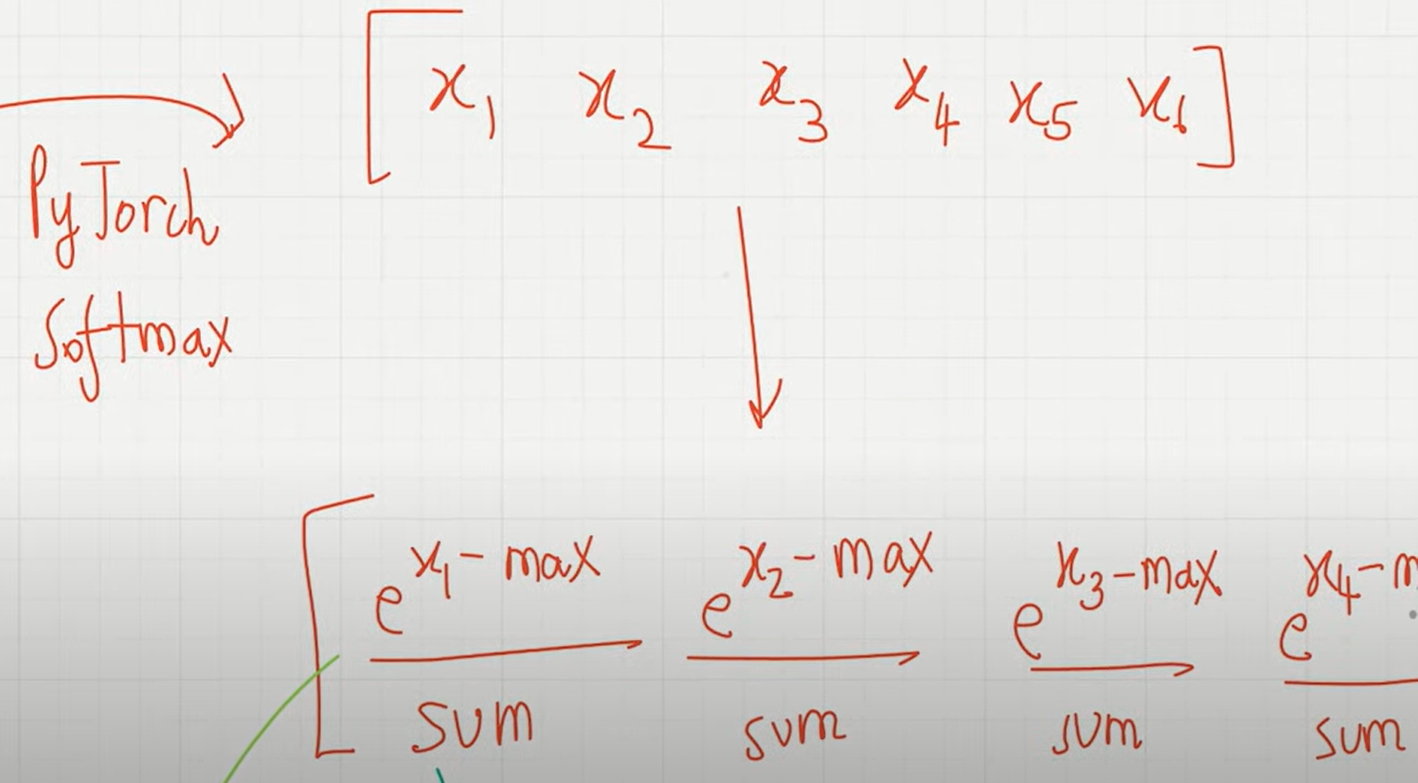


In [13]:
atten_weights = torch.softmax(atten_score,dim=0)
print(atten_weights) #(6,)
print(atten_weights.sum()) 

tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])
tensor(1.)


## Context vector 

<div class="alert alert-block alert-success">

The context vector is calculated as a weighted sum of all input
vectors. 

This involves multiplying each input vector by its corresponding attention weight:

</div>

In [21]:
con_vec = atten_weights @ inputs #(6,) @ (6,3) -> (3,)
print(con_vec) #(3,)

tensor([0.4419, 0.6515, 0.5683])


Before that 1st i am creating the attentions scores matrix of the whole words array to earh other.

In [17]:
attention_score = inputs @ inputs.T #(6,3) @ (3,6) -> (6,6)
print(attention_score)


tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])


Attention weight of all the elements with each other .

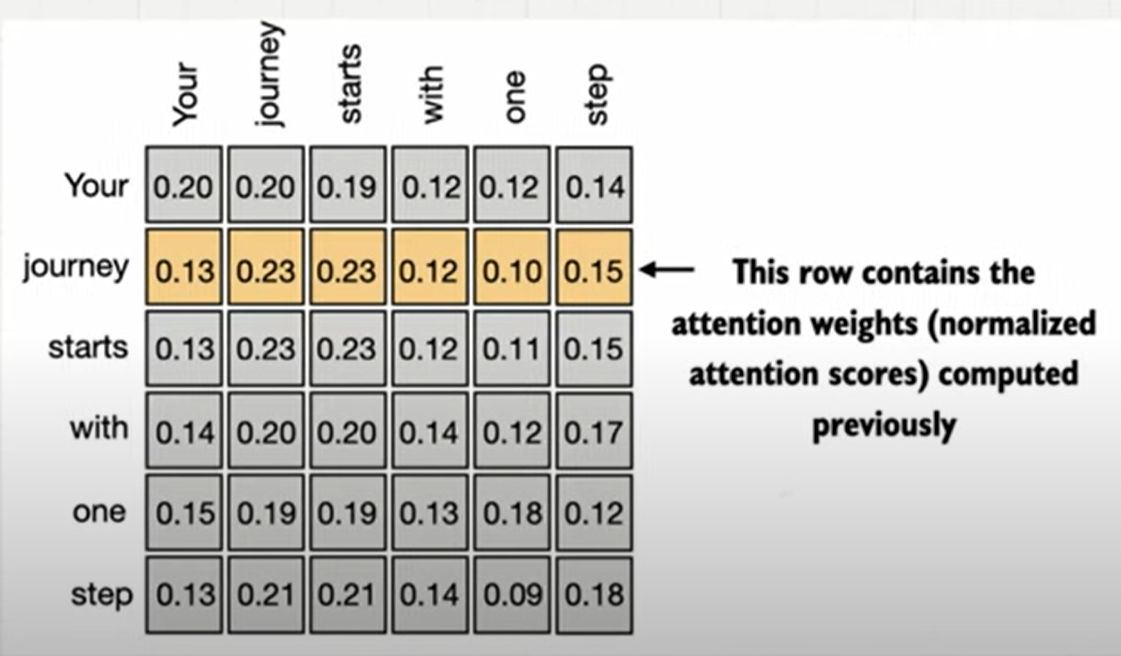

In [18]:
attention_weights  = torch.softmax(attention_score,dim=1) #(6,6)
print(attention_weights)

tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])


<div class="alert alert-block alert-success">

In the third and last step, we now use these attention weights to compute all context
vectors via matrix multiplication:

</div>

In [20]:
context_vector = attention_weights @ inputs #(6,6) @ (6,3) -> (6,3)
print(context_vector)

tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])
